In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
#1. import the data
conn = sqlite3.connect('customer_churn.db')

sql_query = """      
        SELECT name 
        FROM sqlite_master
        WHERE type='table'
""" 
tables = pd.read_sql(sql_query, conn)

#create data frame from each table
for table_name in tables["name"]:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [3]:
#print table names and columns names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables["name"]:
    print(f"\nTable Name : {table_name}")
    
    #get columns informantion
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns["name"].tolist())

#close the connection
conn.close()


Table Name : db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name : db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name : db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [4]:
# 2. data cleaning (1.Table Name : db_customer)

In [5]:
# df_db_customer.head()

df_db_customer.tail()


,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [7]:
# a. rename column - name
# b. drop columns - interest and pincode
# c. change data type of column - date_of_birth
# d. data standardization - gender
# e. fix missing values - country


In [8]:
# a. rename column - name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)

df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [9]:
# b. drop columns - interest and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], inplace = True, axis = 1)

df_db_customer.drop(['interests', 'pincode'], inplace = True, axis = 1)
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [10]:
# c. change data type of column - date_of_birth(dob)

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [11]:
# d. data standardization - gender

# df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men': 'Male', 'Women': 'Female'})

In [12]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [13]:
# e. fix missing values - country

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [14]:
# country and state - unique value pair

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [15]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [16]:
# data cleaning (2. Table Name : db_subscription)

In [17]:

df_db_subscription.head()

# df_db_subscription.tail()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [18]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [19]:
data_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']

df_db_subscription[data_col] = df_db_subscription[data_col].apply(pd.to_datetime)

df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [20]:
# data cleaning (3. Table Name : db_support)

In [21]:
df_db_support.head()

# df_db_support.tail()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [22]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [23]:
df_db_support.drop(columns=['col_1', 'comment'], inplace = True, axis = 1)

In [24]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


In [25]:
# 3. Feature Engineering and Data Analysis

In [26]:
# 3.1 Create a new column using existing column - churn_flag

df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [27]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [28]:
# 3.2 First fix support table duplicates then merge

df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how = 'left')
            .merge(df_db_support, on = 'customerid', how = 'left') )

In [29]:
df_db_subscription.shape

(21, 12)

In [30]:
df.shape

(23, 20)

In [31]:
df_db_subscription['customerid'].nunique()

21

In [32]:
df_db_customer['customerid'].nunique()

21

In [33]:
df_db_support['customerid'].nunique()

7

In [34]:
df_db_support['customerid'].size

9

In [35]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [36]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [37]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [38]:
df_db_support['customerid'].size

7

In [39]:
# 3.3 merge df

df = (df_db_subscription
            .merge(df_db_customer, on = 'customerid', how = 'left')
            .merge(df_db_support, on = 'customerid', how = 'left') )

In [40]:
df.shape

(21, 21)

In [41]:
df.to_csv('exported_churn_data.csv', index=False)

In [42]:
# Data Analysis 

# 3.4 Churn Rate

In [43]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [44]:
churn_rate = df['churn_flag'].mean() * 100
print("Churn Rate = ", round(churn_rate, 2), "%")

Churn Rate =  28.57 %


In [45]:
# 3.5 Retention Rate

retention_rate = 100 - churn_rate
print("Retention Rate = ", round(retention_rate, 2), "%")

Retention Rate =  71.43 %


In [46]:
# 3.6 Churn By Plan Type

churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).reset_index(name = 'churn_rate_pct'))  
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic       60.000000
1   Premium       14.285714
2  Standard       22.222222


In [47]:
# 3.7 a. Churn By State + sum(revenue) & count of users

churn_by_state = df.groupby('state').agg(churn_rate_pct = ('churn_flag', lambda x: round(x.mean() * 100, 2)), total_revenue = ('monthly_charges', 'sum'), user_count = ('customerid', 'count')).reset_index()
print(churn_by_state)

           state  churn_rate_pct  total_revenue  user_count
0          Delhi           25.00          52.96           4
1      Karnataka          100.00          20.98           2
2      Kathmandu            0.00          20.98           2
3    Maharashtra            0.00          50.97           3
4      Meghalaya           66.67          42.97           3
5       Nagaland            0.00          22.99           1
6      Rajasthan            0.00          36.98           2
7      Telangana           50.00          30.98           2
8  Uttar Pradesh            0.00         115.98           2


In [48]:
# 3.8 b. Churn By Subscription Type + sum(revenue) & count of users

churn_by_subscription = df.groupby('subscription_type').agg(churn_rate_pct = ('churn_flag', lambda x: round(x.mean() * 100, 2)), total_revenue = ('monthly_charges', 'sum'), user_count = ('customerid', 'count')).reset_index()
print(churn_by_subscription)

  subscription_type  churn_rate_pct  total_revenue  user_count
0           Organic            0.00         145.91           9
1              Paid           16.67         174.94           6
2          Refferal           83.33          74.94           6


In [49]:
# 3.9 ARPU - Avg Revenue per user

arpu = df['monthly_charges'].mean()
print('ARPU = ', round(arpu,2))

ARPU =  18.85


In [50]:
# 3.10 Calculate Customer Age

today = pd.Timestamp.today()

df['customer_age'] = today.year - df['dob'].dt.year

df.loc[
    (today.month < df['dob'].dt.month) | 
    ((today.month == df['dob'].dt.month) & (today.day < df['dob'].dt.day)),
    'customer_age'
] -= 1

df[['customer_name', 'dob', 'customer_age']].head()


,customer_name,dob,customer_age
0,keshav,1982-04-12,44
1,raghav,1995-11-23,30
2,lalita,1978-02-15,48
3,mohan,2001-08-30,24
4,mira,1990-05-05,36


In [51]:
# 3.11 Avg Customer Tenure
# count of days users has used our service : cancellation date else current date 

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),
    
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,
    
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure(Days) = ", round(avg_tenure))

Avg Tenure(Days) =  1502


In [52]:
# 3.12 Revenue at Risk - revenue last from churned users

revenue_at_risk = df.loc[df['churn_flag'] == 1, 'monthly_charges'].sum()
print("Revenue at Risk(Rs 'K') = ", revenue_at_risk)

Revenue at Risk(Rs 'K') =  73.94


In [53]:
# 3.13 Esclation Rate

escalation_rate = (df['escalations'] == 'Y').mean()*100
print("Escalation Rate = ", round(escalation_rate, 2), "%")

Escalation Rate =  19.05 %


In [54]:
# 3.14 Avg Complaint Rate Per user

avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaints Per User = ", round(avg_complaints, 2))


Avg Complaints Per User =  0.43


In [55]:
# 3.15 Correlation Escalations vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type

corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between vs Churn is = ", round(correlation, 2))

Correlation between vs Churn is =  0.77


In [56]:
# 3.16 Create a Column using existing column - Churn Risk

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >=50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default = 'unkown')

In [57]:
df[['churn_risk', 'churn_score']].tail()

,churn_risk,churn_score
16,med,62
17,low,27
18,high,99
19,low,7
20,low,47


In [58]:
# 4. Visualization Using Matplotlib

In [59]:
df_visual = df.copy()

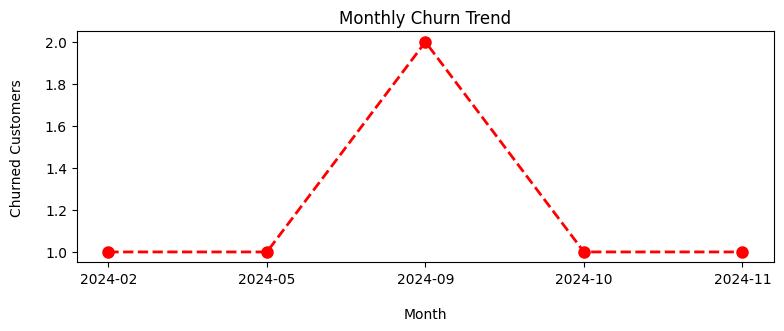

In [60]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize = (9,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,color = 'red', marker = 'o', linestyle = '--', linewidth = 2, markersize = 8)

plt.title('Monthly Churn Trend')
plt.xlabel('Month', labelpad = 15)
plt.ylabel('Churned Customers', labelpad = 15)
plt.show()

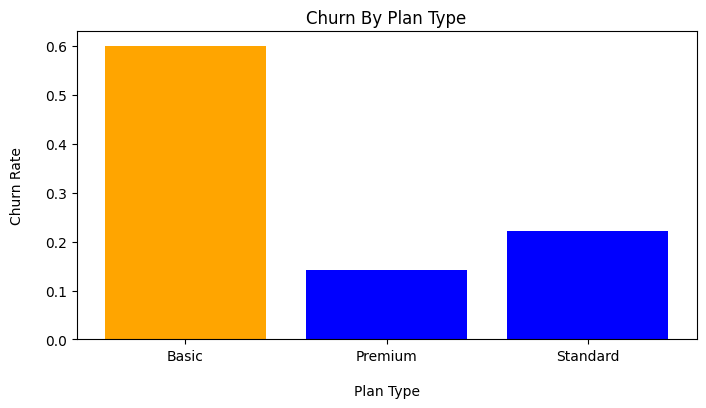

In [61]:
# 4.2 Churn By Plan Type

churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

colors = ['orange', 'blue', 'blue']

plt.figure(figsize = (8,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.title("Churn By Plan Type")
plt.xlabel("Plan Type", labelpad = 15)
plt.ylabel("Churn Rate", labelpad = 15)

plt.show()

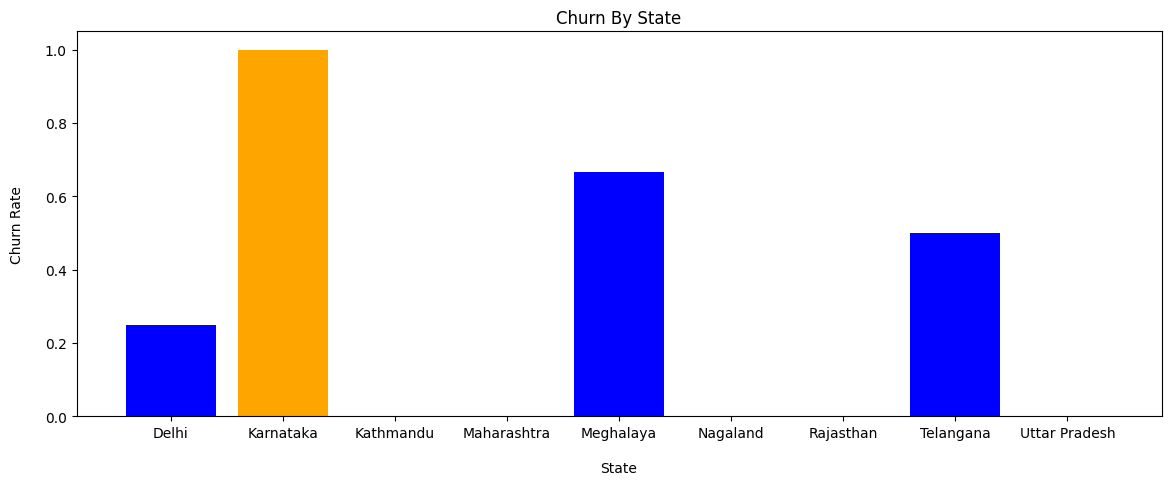

In [62]:
# 4.3 Churn By State

churn_state = df_visual.groupby('state')['churn_flag'].mean()

colors = ['blue', 'orange', 'blue', 'blue']

plt.figure(figsize = (14,5))
plt.bar(churn_state.index, churn_state.values, color = colors)

plt.title("Churn By State")
plt.xlabel("State", labelpad = 15)
plt.ylabel("Churn Rate", labelpad = 15)

plt.show()

In [63]:
# 4.4 Churn By Age Group

df_visual['customer_age'].min()

np.int32(21)

In [64]:
df_visual['customer_age'].max()

np.int32(49)

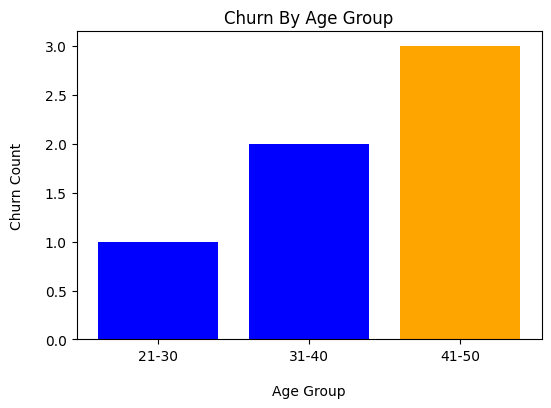

In [65]:
df_visual['age_group'] = pd.cut(df_visual['customer_age'], bins = [20, 30, 40, 50], labels = ['21-30', '31-40', '41-50'])

churn_age = df_visual.groupby('age_group', observed = False)['churn_flag'].sum()

colors = ['blue', 'blue', 'orange']

plt.figure(figsize = (6,4))
plt.bar(churn_age.index, churn_age.values, color = colors)

plt.title("Churn By Age Group")
plt.xlabel("Age Group", labelpad = 15)
plt.ylabel("Churn Count", labelpad = 15)

plt.show()

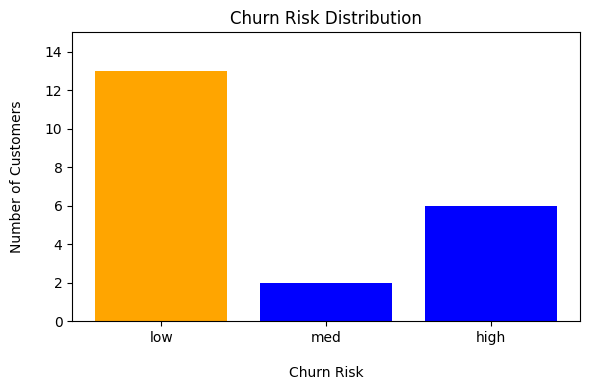

In [66]:
# 4.5 Churn Risk Distribution

churn_risk = df_visual['churn_risk'].value_counts().reindex(['low', 'med', 'high'])

colors = ['orange', 'blue', 'blue']

plt.figure(figsize = (6,4))

plt.bar(churn_risk.index, churn_risk.values, color = colors)

plt.title("Churn Risk Distribution")
plt.xlabel("Churn Risk", labelpad = 15)
plt.ylabel("Number of Customers", labelpad = 15)

plt.ylim(0, max(churn_risk.values) + 2)

plt.tight_layout()
plt.show()

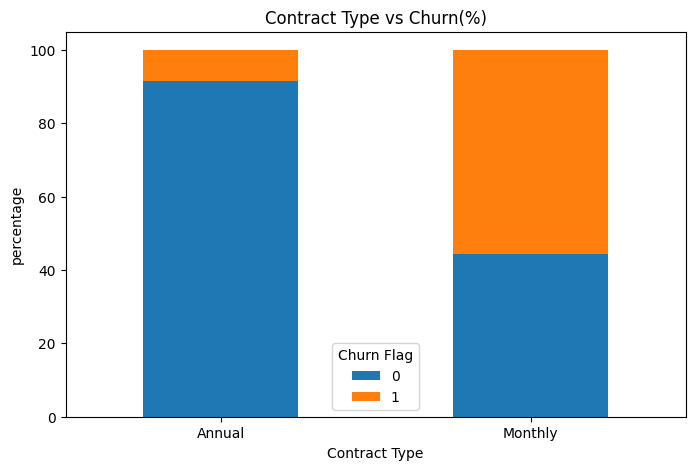

In [67]:
# 4.6 Contract Type vs Churn 

contract = pd.crosstab(df_visual['contract_type'], df_visual['churn_flag'], normalize = 'index')*100

contract.plot(kind = 'bar', stacked = True, figsize = (8,5))

plt.title("Contract Type vs Churn(%)")
plt.xlabel("Contract Type")
plt.ylabel("percentage")
plt.xticks(rotation = 0)
plt.legend(title = "Churn Flag")

plt.show()

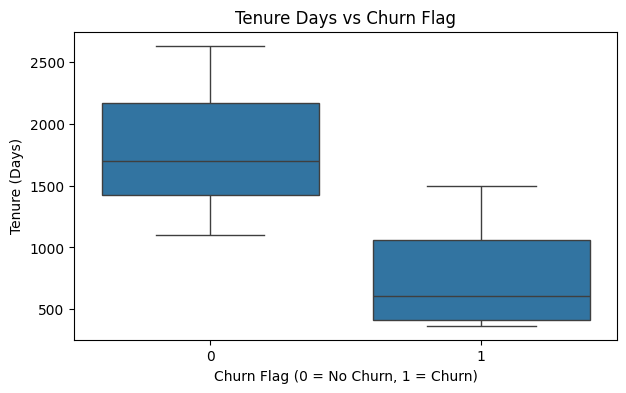

In [68]:
# 4.7 Tenure Days vs Churn Analysis

plt.figure(figsize = (7,4))

sns.boxplot(x = 'churn_flag', y = 'tenure_days', data = df_visual)

plt.title("Tenure Days vs Churn Flag")
plt.xlabel("Churn Flag (0 = No Churn, 1 = Churn)")
plt.ylabel("Tenure (Days)")

plt.show()

In [69]:
# 5 Visualization using Seaborn

In [70]:
# encoding - convert str to matrix so that we can find corr between features

df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'customer_age', 'tenure_days', 'churn_risk', 'cancellation_month',
       'age_group'],
      dtype='object')

In [71]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,0
1,Premium,Annual,91,1,high,1
2,Basic,Monthly,34,0,low,0
3,Premium,Annual,8,0,low,0
4,Standard,Monthly,88,1,high,1


In [72]:
import warnings
warnings.filterwarnings("ignore")

In [73]:
# Correct meethod of encoding - based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk' : ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories = order, ordered = True).codes

In [74]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0
1,2,1,91,1,2,1
2,0,0,34,0,0,0
3,2,1,8,0,0,0
4,1,0,88,1,2,1


<Axes: >

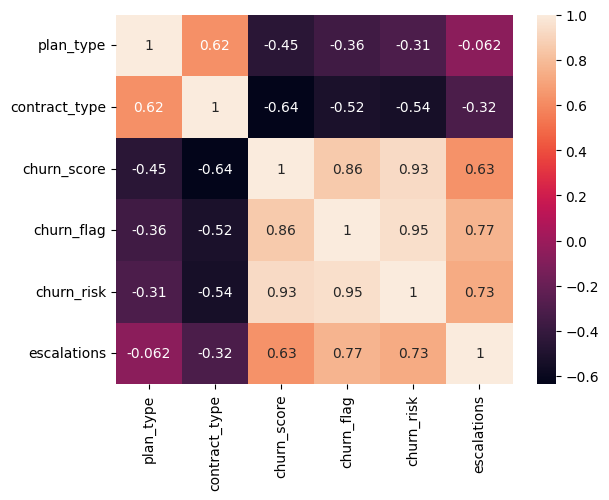

In [75]:
# 5.1 Heatmap (correlation matrix)

sns.heatmap(df_encoded.corr(), annot = True)

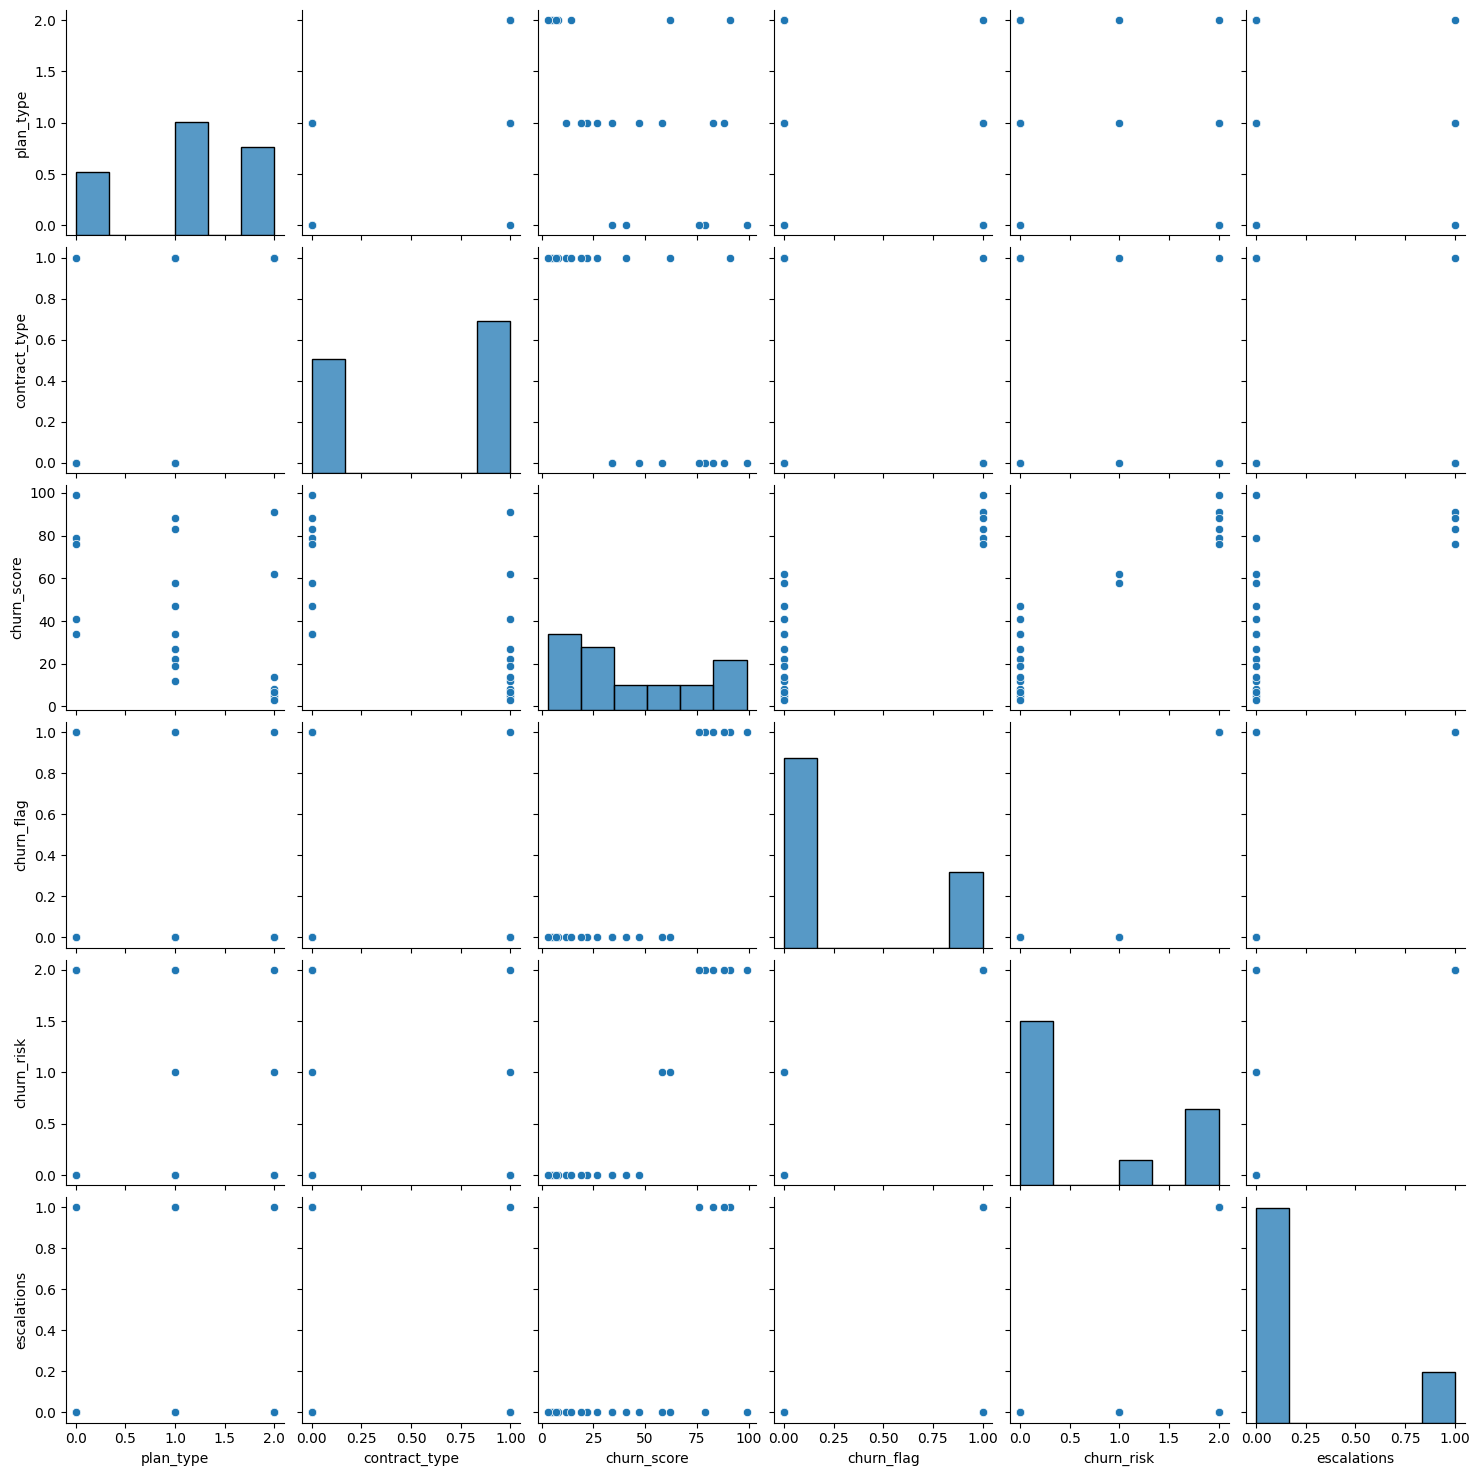

In [76]:
# 5.2 pairplot - relationship in a dataset 

sns.pairplot(df_encoded)

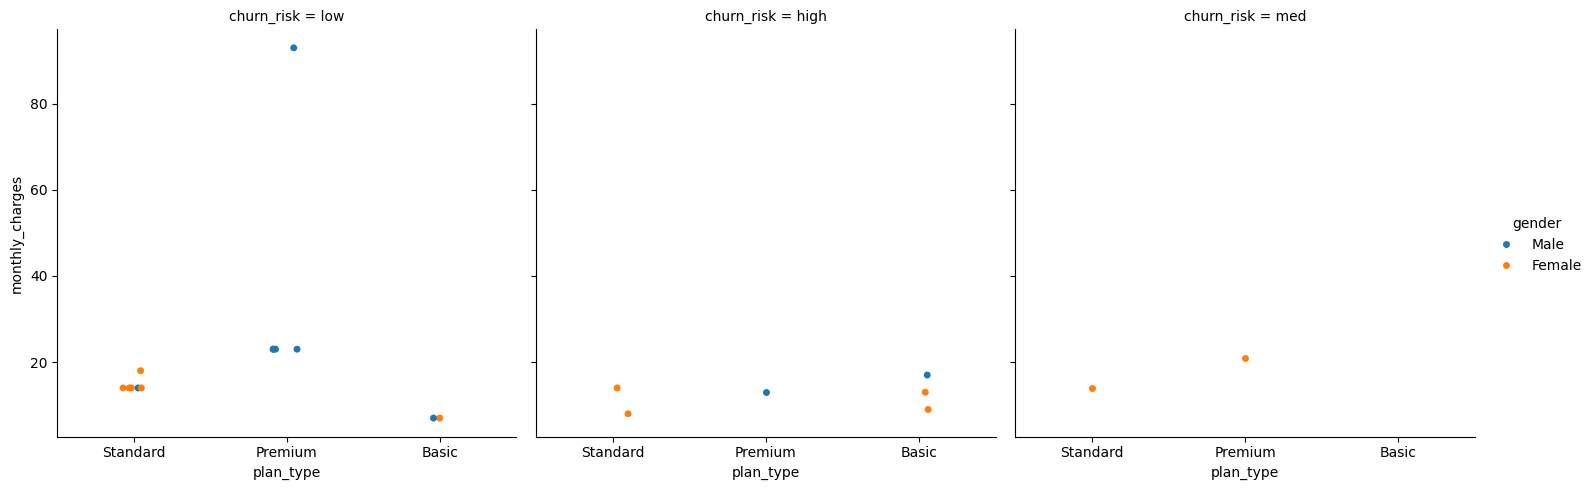

In [77]:
# 5.3 catplt/Facegrid plot - multi - dimantion camparison

sns.catplot(data = df_visual,
            x = 'plan_type',
            y = 'monthly_charges',
            hue = 'gender',
            col = 'churn_risk'
            )

In [78]:
# 6. Pivot Table

In [79]:
pd.pivot_table(
         df_visual,
         values = 'churn_flag',
         index = 'plan_type',
         aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [80]:
pd.pivot_table(
         df_visual,
         index = 'plan_type',
         values = ['churn_flag', 'monthly_charges', 'customerid'],
         aggfunc = {
             'churn_flag' : 'mean',
             'monthly_charges' : 'sum',
             'customerid' : 'nunique'
         }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


## Business Insights

- The overall churn analysis highlights customer retention patterns across different plans, contract types, age groups, and states.
- Customers with higher churn scores are more likely to cancel their subscriptions, making churn score an important indicator for identifying at-risk customers.
- Monthly contract customers show a higher tendency to churn compared to annual contract customers, suggesting that long-term contracts improve customer retention.
- Customer tenure has a significant impact on churn, as customers with shorter tenure are more likely to leave than long-term customers.
- Churn behavior varies across different plan types and states, indicating that targeted retention strategies should be designed for specific customer segments.
- Customers classified as **High Churn Risk** require immediate attention through personalized offers, loyalty programs, or proactive customer support.
- Revenue at risk from churned customers highlights the financial impact of customer attrition and emphasizes the importance of retention strategies.
- Monitoring escalations, customer complaints, and churn trends over time can help businesses identify issues early and reduce future churn.

In [81]:
# 7. Working with SQL in Python (Pandas)

In [82]:
# create db in SQL

conn = sqlite3.connect('test_database.sqlite')

#Table Details
conn.execute("CREATE TABLE user (first_name TEXT, country TEXT, budget INTEGER)")

# commit and save
conn.commit()

In [83]:
# insert data 

cursor = conn.cursor()

# write sql query to insert records i sql table
cursor.execute(
    """
    INSERT INTO user VALUES
        ('Hemant', 'India', 8000),
        ('Darshit', 'USA', 5000),
        ('Shiv', 'India', 7000)
    """
)

# commit and save
conn.commit()

print("Data Inserted Successfully!")

Data Inserted Successfully!


In [84]:
# Check inserted data in table

conn = sqlite3.connect('test_database.sqlite')

query = """SELECT * FROM user"""

df_result = pd.read_sql(query, conn)

df_result.head()

,first_name,country,budget
0,Hemant,India,8000
1,Darshit,USA,5000
2,Shiv,India,7000


In [85]:
# aggregation

query = """
        SELECT country, sum(budget) as total_budget
        FROM user
        GROUP BY country
"""

df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,India,15000
1,USA,5000


In [86]:
# Always close the conn with db once the task is over

conn.close()

## Conclusion

This project successfully analyzed customer churn data to identify the key factors influencing customer retention. The analysis showed that customer behavior, contract type, tenure, payment preferences, and churn risk significantly affect churn patterns. Data cleaning, exploratory data analysis, SQL queries, and visualizations provided meaningful insights into customer trends. These findings can help businesses identify high-risk customers, improve retention strategies, and make data-driven decisions to reduce customer churn and increase long-term business growth.